### Edible Plants Database EDA

#### Importing necessary libraries

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [159]:
dataset=pd.read_csv("data/edible_plants.csv")
dataset.head()

,taxonomic_name,common_name,cultivation,sunlight,water,preferred_ph_lower,preferred_ph_upper,nutrients,soil,season,temperature_class,temperature_germination,temperature_growing,days_germination,days_harvest,nutritional_info,energy,sensitivities,description,requirements
0,Pisum sativum,Pea,Legume,Full sun,Very High,6.0,7.5,Medium,Loamy,Annual,Half hardy,24,4-24,6,55-75,"A good source of vitamin K, manganese, and die...",80.0,Drought intolerant,"The pea is the small spherical seed, or the se...","Require a sunny, nutrient-rich, moisture-reten..."
1,Phaseolus coccineus,Beans (Runner),Legume,Full sun,Medium,6.0,6.8,Medium,Loamy and clay,Annual,Tender,26,16-30,7,65-85,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,Runner bean plants are more productive than gr...,"Beans are a tender, warm-weather crop. They ar..."
2,Phaseolus vulgari,Beans (French),Legume,Full sun,Medium,6.0,7.5,Medium,Any well-drained and fertile,Annual,Tender,26,16-30,7,40-55,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,"French beans are the unripe fruit, and protect...","Beans are a tender, warm-weather crop. They ar..."
3,Vicia faba,Beans (Broad),Legume,Full sun/partial shade/full shade,Very Low,6.0,7.0,Medium,Any well-drained and fertile,Annual,Hardy,10,8-15,7,85-115,"A good source of vitamin-B6 (pyridoxine), thia...",88.0,Drought intolerant,Broad beans - also known as the fava bean - ar...,Broad beans are a cool weather crop. They grow...
4,Brassica oleracea,Cabbage (Spring),Legume,Full sun,High,6.0,7.5,High,Sand/loam/clay,biennial,Hardy,26,7-30,4,55-85,"A very good source of manganese, dietary fibre...",25.0,Particularly vulnerable to pests. Do not grow ...,Cabbages are a leafy green or purple biennial ...,Cabbage is a cool-season crop best planted in ...


In [160]:
dataset.describe()

,preferred_ph_lower,preferred_ph_upper,energy
count,140.000000,140.000000,12.000000
mean,5.832143,7.114286,35.666667
std,0.422440,0.476433,26.568379
min,4.500000,6.000000,0.000000
25%,5.500000,7.000000,26.500000
50%,6.000000,7.000000,31.000000
75%,6.000000,7.500000,38.750000
max,7.000000,8.500000,88.000000


In [161]:
dataset.dtypes

taxonomic_name              object
common_name                 object
cultivation                 object
sunlight                    object
water                       object
preferred_ph_lower         float64
preferred_ph_upper         float64
nutrients                   object
soil                        object
season                      object
temperature_class           object
temperature_germination     object
temperature_growing         object
days_germination            object
days_harvest                object
nutritional_info            object
energy                     float64
sensitivities               object
description                 object
requirements                object
dtype: object

In [162]:
dataset.columns

Index(['taxonomic_name', 'common_name', 'cultivation', 'sunlight', 'water',
       'preferred_ph_lower', 'preferred_ph_upper', 'nutrients', 'soil',
       'season', 'temperature_class', 'temperature_germination',
       'temperature_growing', 'days_germination', 'days_harvest',
       'nutritional_info', 'energy', 'sensitivities', 'description',
       'requirements'],
      dtype='object')

In [163]:
(dataset.isna().sum()/dataset.shape[0]) * 100

taxonomic_name              0.000000
common_name                 0.000000
cultivation                 0.000000
sunlight                    0.000000
water                       0.000000
preferred_ph_lower          0.000000
preferred_ph_upper          0.000000
nutrients                   0.000000
soil                       32.857143
season                     52.142857
temperature_class           0.000000
temperature_germination    25.714286
temperature_growing        58.571429
days_germination           27.142857
days_harvest               19.285714
nutritional_info           92.142857
energy                     91.428571
sensitivities              90.714286
description                 0.000000
requirements                0.000000
dtype: float64

#### Exploratory Data Analysis

##### Analyzing the cultivation feature column

In [164]:
dataset['cultivation'].value_counts()

cultivation
Miscellaneous     65
Brassica          21
Legume            10
Allium             9
Cucurbit           8
Umbelliferae       8
Solanaceae         6
Lamiaceae          4
Salad              3
Chenopodiaceae     3
Solanum            2
Brassicas          1
Name: count, dtype: int64

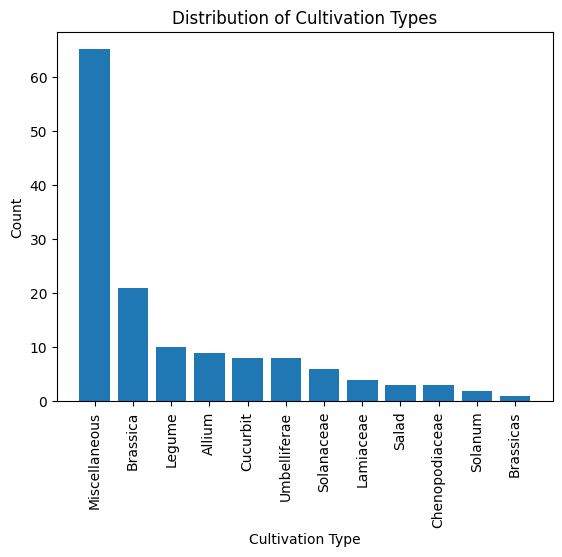

In [165]:
plt.bar(dataset['cultivation'].value_counts().index, dataset['cultivation'].value_counts().values)
plt.xlabel('Cultivation Type')
plt.ylabel('Count')
plt.title('Distribution of Cultivation Types')
plt.xticks(rotation=90)
plt.show()

##### Analyzing the Sunlight Feature column

In [166]:
dataset['sunlight'].value_counts()

sunlight
Full sun                              87
Full sun/partial shade                44
Partial shade                          5
Full sun/partial shade/full shade      2
partial shade                          1
full sun/partial shade/ full shade     1
Name: count, dtype: int64

In [167]:
dataset['sunlight'] = dataset['sunlight'].str.lower()

In [168]:
dataset[dataset['sunlight']=='full sun/partial shade/ full shade']['sunlight']='full sun/partial shade/full shade'

C:\Users\aadit\AppData\Local\Temp\ipykernel_13720\2098468352.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[dataset['sunlight']=='full sun/partial shade/ full shade']['sunlight']='full sun/partial shade/full shade'


In [169]:
dataset['sunlight'].value_counts()

sunlight
full sun                              87
full sun/partial shade                44
partial shade                          6
full sun/partial shade/full shade      2
full sun/partial shade/ full shade     1
Name: count, dtype: int64

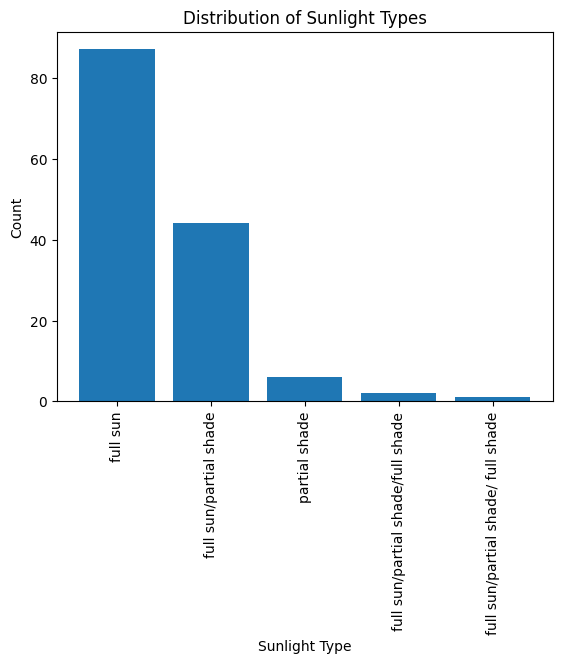

In [170]:
plt.bar(dataset['sunlight'].value_counts().index, dataset['sunlight'].value_counts().values)
plt.xlabel('Sunlight Type')
plt.ylabel('Count')
plt.title('Distribution of Sunlight Types')
plt.xticks(rotation=90)
plt.show()

##### Analyzing the water feature column

In [171]:
dataset['water'].value_counts()

water
Medium       93
High         24
Low          18
Very High     1
Very Low      1
very high     1
Very low      1
high          1
Name: count, dtype: int64

In [172]:
dataset['water']=dataset['water'].str.lower()
dataset['water'].value_counts()

water
medium       93
high         25
low          18
very high     2
very low      2
Name: count, dtype: int64

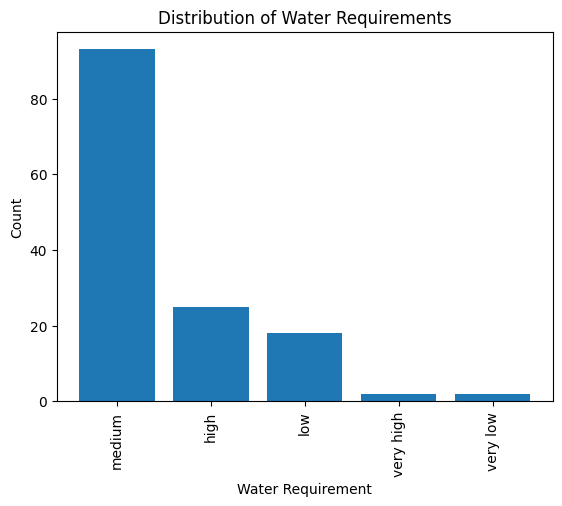

In [173]:
plt.bar(dataset['water'].value_counts().index, dataset['water'].value_counts().values)
plt.xlabel('Water Requirement')
plt.ylabel('Count')
plt.title('Distribution of Water Requirements')
plt.xticks(rotation=90)
plt.show()

##### Analyzing the preferred ph_lower feature column

In [174]:
print(dataset['preferred_ph_lower'].value_counts())

preferred_ph_lower
6.0    77
5.5    39
6.5    10
5.0     9
7.0     3
4.5     2
Name: count, dtype: int64


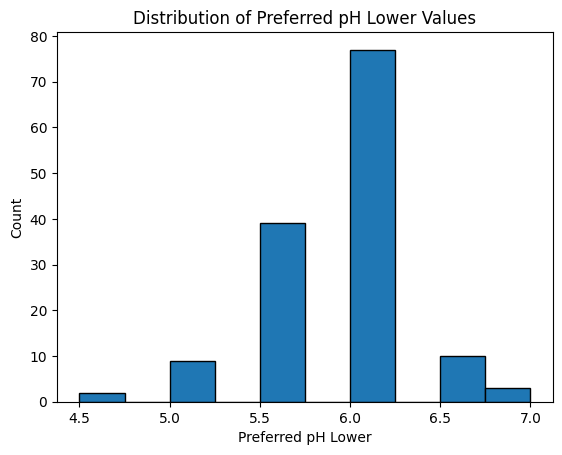

In [175]:
plt.hist(dataset['preferred_ph_lower'].dropna(), edgecolor='black')
plt.xlabel('Preferred pH Lower')
plt.ylabel('Count')
plt.title('Distribution of Preferred pH Lower Values')
plt.show()

##### Analyzing the preferred_ph_higher feature column

In [176]:
print(dataset['preferred_ph_upper'].value_counts())


preferred_ph_upper
7.0    69
7.5    41
6.5    10
6.0     9
8.0     7
8.5     2
6.8     1
6.7     1
Name: count, dtype: int64


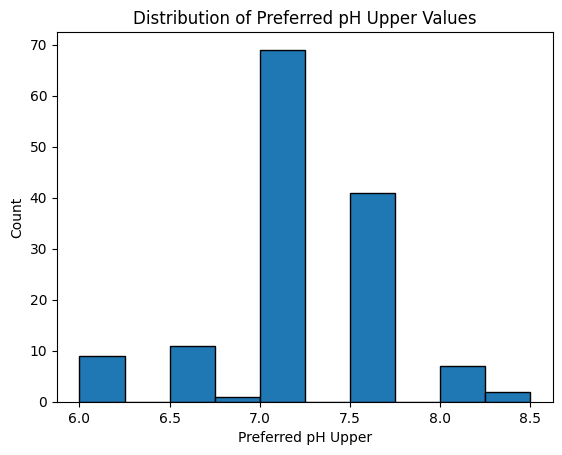

In [177]:
plt.hist(dataset['preferred_ph_upper'].dropna(), edgecolor='black')
plt.xlabel('Preferred pH Upper')
plt.ylabel('Count')
plt.title('Distribution of Preferred pH Upper Values')
plt.show()

##### Analyzing the nutrients feature column

In [178]:
dataset['nutrients'].value_counts()

nutrients
Medium                                      58
Low                                         48
High                                        28
High potassium fertiliser every 2 weeks.     2
low                                          2
high                                         1
Medium to high                               1
Name: count, dtype: int64

In [179]:
dataset['nutrients']=dataset['nutrients'].str.lower()
dataset.loc[dataset['nutrients']=='high potassium fertiliser every 2 weeks.','nutrients']='high'
dataset.loc[dataset['nutrients']=='medium to high','nutrients']='high'
dataset['nutrients'].value_counts()

nutrients
medium    58
low       50
high      32
Name: count, dtype: int64

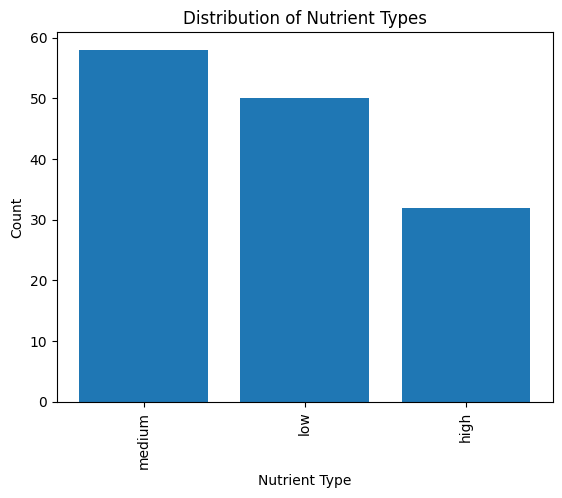

In [180]:
plt.bar(dataset['nutrients'].value_counts().index, dataset['nutrients'].value_counts().values)
plt.xlabel('Nutrient Type')
plt.ylabel('Count')
plt.title('Distribution of Nutrient Types')
plt.xticks(rotation=90)
plt.show()

##### Analyzing the soil feature column

In [181]:
dataset['soil'].value_counts()

soil
Loamy                                                               20
Any well-drained and fertile                                         8
Loamy and sandy                                                      7
Loam, Chalk, Sand                                                    7
Sand/loam/clay                                                       7
Chalk, Clay, Sand, Loam                                              5
Loamy, clay and sandy                                                4
Loamy and clay                                                       3
Loam                                                                 3
Sand, Clay, Chalk, Loam                                              2
Sandy                                                                2
Loamy, sandy and silty                                               2
Loamy soil                                                           2
Loam, Sand                                                           2
W

In [182]:
dataset['soil']=dataset['soil'].str.lower()
dataset.loc[dataset['soil']=='any well-drained and fertile', 'soil']='well-drained and fertile'

##### Analyzing the season feature column

In [183]:
dataset['season'].value_counts()

season
Perennial                       37
Annual                          12
biennial                         8
biennial, grown as annual        2
perennial                        2
Perrenial                        1
Annual/perannial                 1
Biennial, grown as an annual     1
Shrub                            1
Perrenial evergreen              1
Semi-evergreen perrenial         1
Name: count, dtype: int64

In [184]:
dataset['season']=dataset['season'].str.lower()
dataset.loc[dataset['season']=='biennial, grown as an annual','season']='biennial, grown as annual'
dataset['season'] = dataset['season'].replace({
    'perrenial': 'perennial',
    'perrenial evergreen': 'perennial',
    'semi-evergreen perrenial': 'perennial',
    'annual/perannial': 'perennial',
    'biennial, grown as annual': 'biennial'
})
dataset['season'].value_counts()

season
perennial    43
annual       12
biennial     11
shrub         1
Name: count, dtype: int64

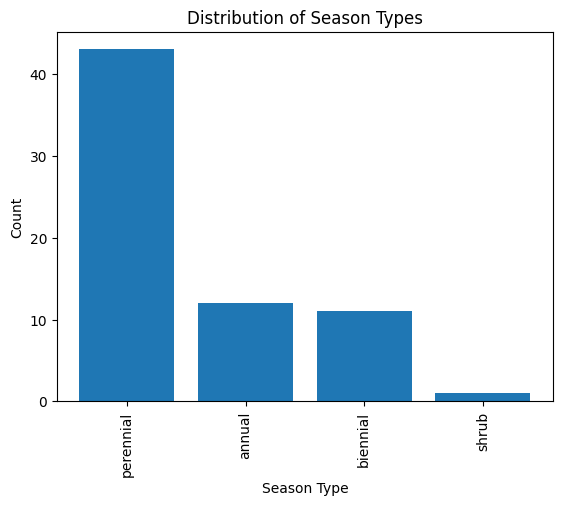

In [185]:
plt.bar(dataset['season'].value_counts().index, dataset['season'].value_counts().values)
plt.xlabel('Season Type')
plt.ylabel('Count')
plt.title('Distribution of Season Types')
plt.xticks(rotation=90)
plt.show()

##### Analyzing the temperature class column

In [186]:
dataset['temperature_class'].value_counts()

temperature_class
Hardy          67
Tender         37
Very hardy     21
Half hardy     12
Very tender     2
Very hard       1
Name: count, dtype: int64

In [187]:
dataset['temperature_class']=dataset['temperature_class'].str.lower()
dataset.loc[dataset['temperature_class']=='very hard', 'temperature_class']='very hardy'
dataset['temperature_class'].value_counts()

temperature_class
hardy          67
tender         37
very hardy     22
half hardy     12
very tender     2
Name: count, dtype: int64

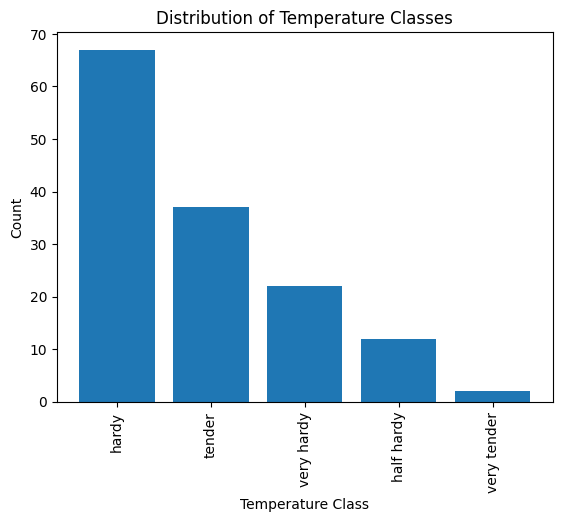

In [188]:
plt.bar(dataset['temperature_class'].value_counts().index, dataset['temperature_class'].value_counts().values)
plt.xlabel('Temperature Class')
plt.ylabel('Count')
plt.title('Distribution of Temperature Classes')
plt.xticks(rotation=90)
plt.show()

##### Analyzing the temperature germination feature column

In [189]:
dataset['temperature_germination'].describe()

count                 104
unique                 20
top       Not applicable.
freq                   30
Name: temperature_germination, dtype: object

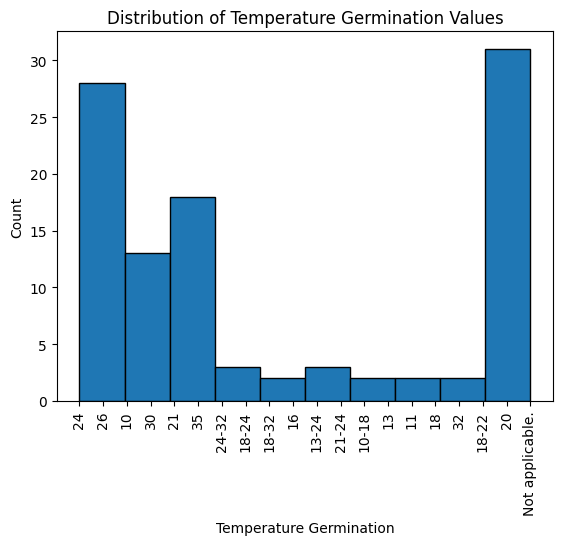

In [190]:
plt.hist(dataset['temperature_germination'].dropna(), edgecolor='black')
plt.xlabel('Temperature Germination')
plt.ylabel('Count')
plt.title('Distribution of Temperature Germination Values')
plt.xticks(rotation=90)
plt.show()

#### Analyzing the temperature growing feature column

In [191]:
dataset[['min_temperature_growing',
         'max_temperature_growing']] = \
dataset['temperature_growing'].str.split('-', expand=True)

dataset['min_temperature_growing']=dataset['min_temperature_growing'].str.strip()
dataset['min_temperature_growing']=pd.to_numeric(dataset['min_temperature_growing'], errors='coerce')
dataset['max_temperature_growing']=dataset['max_temperature_growing'].str.strip()
dataset['max_temperature_growing']=pd.to_numeric(dataset['max_temperature_growing'], errors='coerce')
dataset.head()

,taxonomic_name,common_name,cultivation,sunlight,water,preferred_ph_lower,preferred_ph_upper,nutrients,soil,season,temperature_class,temperature_germination,temperature_growing,days_germination,days_harvest,nutritional_info,energy,sensitivities,description,requirements,min_temperature_growing,max_temperature_growing
0,Pisum sativum,Pea,Legume,full sun,very high,6.0,7.5,medium,loamy,annual,half hardy,24,4-24,6,55-75,"A good source of vitamin K, manganese, and die...",80.0,Drought intolerant,"The pea is the small spherical seed, or the se...","Require a sunny, nutrient-rich, moisture-reten...",4.0,24.0
1,Phaseolus coccineus,Beans (Runner),Legume,full sun,medium,6.0,6.8,medium,loamy and clay,annual,tender,26,16-30,7,65-85,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,Runner bean plants are more productive than gr...,"Beans are a tender, warm-weather crop. They ar...",16.0,30.0
2,Phaseolus vulgari,Beans (French),Legume,full sun,medium,6.0,7.5,medium,well-drained and fertile,annual,tender,26,16-30,7,40-55,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,"French beans are the unripe fruit, and protect...","Beans are a tender, warm-weather crop. They ar...",16.0,30.0
3,Vicia faba,Beans (Broad),Legume,full sun/partial shade/full shade,very low,6.0,7.0,medium,well-drained and fertile,annual,hardy,10,8-15,7,85-115,"A good source of vitamin-B6 (pyridoxine), thia...",88.0,Drought intolerant,Broad beans - also known as the fava bean - ar...,Broad beans are a cool weather crop. They grow...,8.0,15.0
4,Brassica oleracea,Cabbage (Spring),Legume,full sun,high,6.0,7.5,high,sand/loam/clay,biennial,hardy,26,7-30,4,55-85,"A very good source of manganese, dietary fibre...",25.0,Particularly vulnerable to pests. Do not grow ...,Cabbages are a leafy green or purple biennial ...,Cabbage is a cool-season crop best planted in ...,7.0,30.0


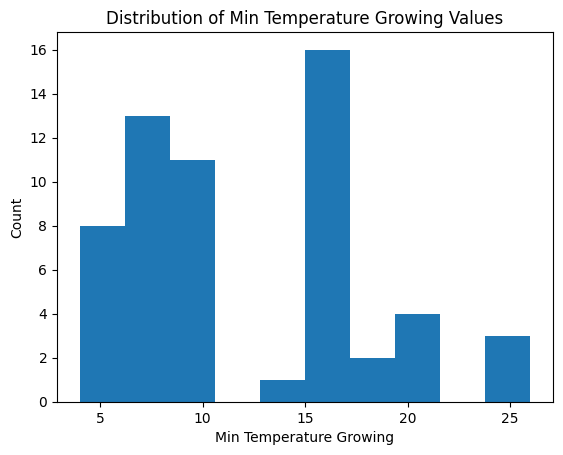

In [192]:
plt.hist(dataset['min_temperature_growing'])
plt.xlabel('Min Temperature Growing')
plt.ylabel('Count')
plt.title('Distribution of Min Temperature Growing Values')
plt.show()

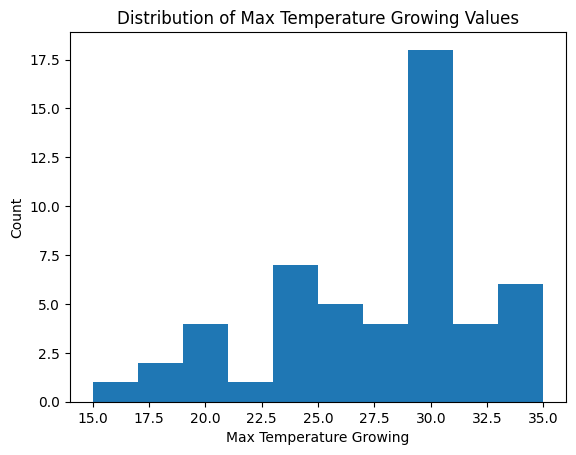

In [193]:
plt.hist(dataset['max_temperature_growing'])
plt.xlabel('Max Temperature Growing')
plt.ylabel('Count')
plt.title('Distribution of Max Temperature Growing Values')
plt.show()

In [194]:
pd.options.display.max_columns = None
dataset.head()

,taxonomic_name,common_name,cultivation,sunlight,water,preferred_ph_lower,preferred_ph_upper,nutrients,soil,season,temperature_class,temperature_germination,temperature_growing,days_germination,days_harvest,nutritional_info,energy,sensitivities,description,requirements,min_temperature_growing,max_temperature_growing
0,Pisum sativum,Pea,Legume,full sun,very high,6.0,7.5,medium,loamy,annual,half hardy,24,4-24,6,55-75,"A good source of vitamin K, manganese, and die...",80.0,Drought intolerant,"The pea is the small spherical seed, or the se...","Require a sunny, nutrient-rich, moisture-reten...",4.0,24.0
1,Phaseolus coccineus,Beans (Runner),Legume,full sun,medium,6.0,6.8,medium,loamy and clay,annual,tender,26,16-30,7,65-85,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,Runner bean plants are more productive than gr...,"Beans are a tender, warm-weather crop. They ar...",16.0,30.0
2,Phaseolus vulgari,Beans (French),Legume,full sun,medium,6.0,7.5,medium,well-drained and fertile,annual,tender,26,16-30,7,40-55,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,"French beans are the unripe fruit, and protect...","Beans are a tender, warm-weather crop. They ar...",16.0,30.0
3,Vicia faba,Beans (Broad),Legume,full sun/partial shade/full shade,very low,6.0,7.0,medium,well-drained and fertile,annual,hardy,10,8-15,7,85-115,"A good source of vitamin-B6 (pyridoxine), thia...",88.0,Drought intolerant,Broad beans - also known as the fava bean - ar...,Broad beans are a cool weather crop. They grow...,8.0,15.0
4,Brassica oleracea,Cabbage (Spring),Legume,full sun,high,6.0,7.5,high,sand/loam/clay,biennial,hardy,26,7-30,4,55-85,"A very good source of manganese, dietary fibre...",25.0,Particularly vulnerable to pests. Do not grow ...,Cabbages are a leafy green or purple biennial ...,Cabbage is a cool-season crop best planted in ...,7.0,30.0


##### Analyzing the Days of Germination feature column

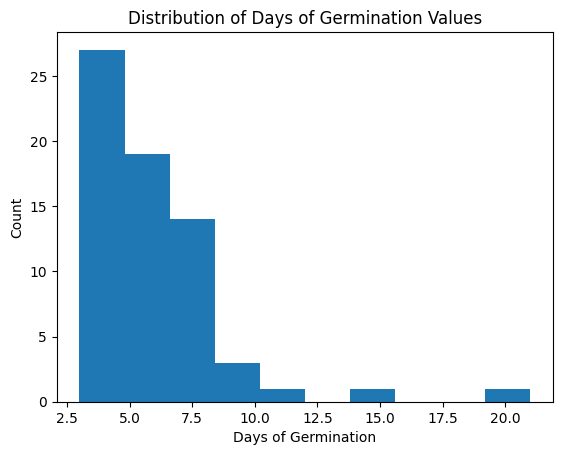

In [195]:
dataset['days_germination']=dataset['days_germination'].str.strip()
dataset['days_germination']=pd.to_numeric(dataset['days_germination'], errors='coerce')
plt.hist(dataset['days_germination'])
plt.xlabel('Days of Germination')
plt.ylabel('Count')
plt.title('Distribution of Days of Germination Values')
plt.show()

##### Analyzing the days to harvest feature column

In [196]:
dataset[['min_days_harvest',
         'max_days_harvest']] = \
dataset['days_harvest'].str.split('-', expand=True)

dataset['min_days_harvest']=dataset['min_days_harvest'].str.strip()
dataset['min_days_harvest']=pd.to_numeric(dataset['min_days_harvest'], errors='coerce')
dataset['max_days_harvest']=dataset['max_days_harvest'].str.strip()
dataset['max_days_harvest']=pd.to_numeric(dataset['max_days_harvest'], errors='coerce')
dataset.head()

,taxonomic_name,common_name,cultivation,sunlight,water,preferred_ph_lower,preferred_ph_upper,nutrients,soil,season,temperature_class,temperature_germination,temperature_growing,days_germination,days_harvest,nutritional_info,energy,sensitivities,description,requirements,min_temperature_growing,max_temperature_growing,min_days_harvest,max_days_harvest
0,Pisum sativum,Pea,Legume,full sun,very high,6.0,7.5,medium,loamy,annual,half hardy,24,4-24,6.0,55-75,"A good source of vitamin K, manganese, and die...",80.0,Drought intolerant,"The pea is the small spherical seed, or the se...","Require a sunny, nutrient-rich, moisture-reten...",4.0,24.0,55.0,75.0
1,Phaseolus coccineus,Beans (Runner),Legume,full sun,medium,6.0,6.8,medium,loamy and clay,annual,tender,26,16-30,7.0,65-85,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,Runner bean plants are more productive than gr...,"Beans are a tender, warm-weather crop. They ar...",16.0,30.0,65.0,85.0
2,Phaseolus vulgari,Beans (French),Legume,full sun,medium,6.0,7.5,medium,well-drained and fertile,annual,tender,26,16-30,7.0,40-55,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,"French beans are the unripe fruit, and protect...","Beans are a tender, warm-weather crop. They ar...",16.0,30.0,40.0,55.0
3,Vicia faba,Beans (Broad),Legume,full sun/partial shade/full shade,very low,6.0,7.0,medium,well-drained and fertile,annual,hardy,10,8-15,7.0,85-115,"A good source of vitamin-B6 (pyridoxine), thia...",88.0,Drought intolerant,Broad beans - also known as the fava bean - ar...,Broad beans are a cool weather crop. They grow...,8.0,15.0,85.0,115.0
4,Brassica oleracea,Cabbage (Spring),Legume,full sun,high,6.0,7.5,high,sand/loam/clay,biennial,hardy,26,7-30,4.0,55-85,"A very good source of manganese, dietary fibre...",25.0,Particularly vulnerable to pests. Do not grow ...,Cabbages are a leafy green or purple biennial ...,Cabbage is a cool-season crop best planted in ...,7.0,30.0,55.0,85.0


##### Analyzing the energy feature column

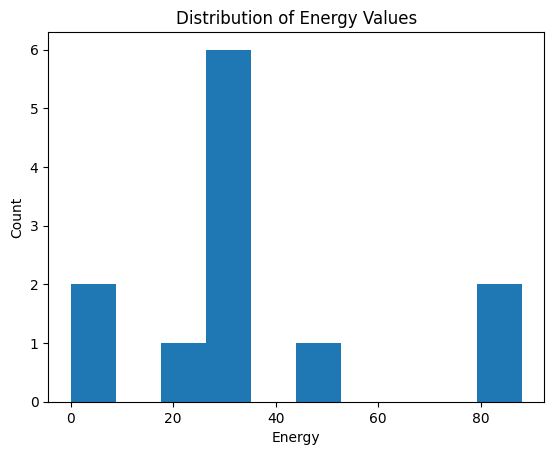

In [197]:
plt.hist(dataset['energy'])
plt.xlabel('Energy')
plt.ylabel('Count')
plt.title('Distribution of Energy Values')
plt.show()

#### Do plants that require more sunlight also require higher temperatures?

##### What cultivation classes require the most water?